
# Notebook 02 — Data Cleaning, Outlier Removal & Data Organization

## Objective

This notebook creates the **clean training/test boundary** for the Amazon ML Challenge product-length prediction project.

The main goals are:

1. Remove invalid records.
2. Remove duplicate records.
3. Detect and remove **right-tail target outliers**.
4. Analyze and remove **genuine left-tail target anomalies**.
5. Protect MAPE-sensitive small targets from being accidentally treated as outliers.
6. Clean text fields.
7. Parse product dimensions from text.
8. Normalize dimensions to centimetres.
9. Impute missing dimensions using training-only statistics.
10. Check train/test leakage and data integrity.
11. Save clean datasets and a complete cleaning audit.

> **Important:** Values such as `PRODUCT_LENGTH <= 10` are investigated first. They are **not automatically deleted**. A low target is removed only when it is statistically anomalous according to the learned lower-tail rule.


## 0. Configuration

In [ ]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)

DATA_MODE = "experiment"      

DATA_PATHS = {
    "debug": "../dataset/sampled/debug",
    "experiment": "../dataset/sampled/experiment",
    "full": "../dataset"
}

DATA_DIR = DATA_PATHS[DATA_MODE]
OUTPUT_DIR = "../dataset/cleaned"

os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_FILE = os.path.join(DATA_DIR, "train.csv")
TEST_FILE = os.path.join(DATA_DIR, "test.csv")

CLEAN_TRAIN_FILE = os.path.join(
    OUTPUT_DIR, f"train_clean_{DATA_MODE}.csv"
)
CLEAN_TEST_FILE = os.path.join(
    OUTPUT_DIR, f"test_clean_{DATA_MODE}.csv"
)
AUDIT_FILE = os.path.join(
    OUTPUT_DIR, f"cleaning_audit_{DATA_MODE}.csv"
)
RULES_FILE = os.path.join(
    OUTPUT_DIR, f"cleaning_rules_{DATA_MODE}.json"
)

# ------------------------------------------------------------
# OUTLIER CONFIGURATION
# ------------------------------------------------------------

# Right-tail:
# log1p(target) > Q3 + multiplier * IQR
RIGHT_IQR_MULTIPLIER = 3.0

# Left-tail:
# log1p(target) < Q1 - multiplier * IQR
LEFT_IQR_MULTIPLIER = 3.0


MIN_LEFT_OUTLIER_COUNT = 1

ABSOLUTE_TARGET_MIN = None
ABSOLUTE_TARGET_MAX = None

MAX_DIMENSION_CM = 100000.0

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


DATA_DIR: ../dataset/sampled/experiment
OUTPUT_DIR: ../dataset/cleaned


## 1. Load data

In [3]:

train_raw = pd.read_csv(TRAIN_FILE)
test_raw = pd.read_csv(TEST_FILE)

print("Raw train shape:", train_raw.shape)
print("Raw test shape :", test_raw.shape)

display(train_raw.head(3))


Raw train shape: (200000, 6)
Raw test shape : (50000, 5)


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
0,667259,Work-Life Balance and Women's Entrepreneurship: An Exploration of Influencing Factors (Contributions to Management S...,NaN,NaN,6046,614.000000
1,1670940,Mower Blades Garden Tools Grass Trimmer 40 Tooth Lawn Steel Cutting Usable Tooth Saw for Gardening Plant Cliping,"[▲ [Premium Quality]- -Adopts quality manganese steel, good toughness, abrasion resistant and durable.,▲ [Easy To Us...","Jeffergarden is a newly-established carftman brand, ""Providing more convenient garden&amp;home improvement tool for ...",5552,39.370079
2,2519657,YES2GOOD Back Case Cover for Oppo K3 Smoke Cover Protective Shockproof Translucent Hybrid Matte Finish Bumper Pouch ...,"[[Matte Translucent Case]: Made by high quality translucent matte non-glossy hard back and soft edges, effectively r...",YES2GOOD Matte Finish Shockproof Hard Back and Side Soft Smoke Back Case Cover can be easily install and removed wit...,12064,787.401574


## 2. Schema validation

In [4]:

REQUIRED_TRAIN = [
    "PRODUCT_ID",
    "TITLE",
    "BULLET_POINTS",
    "DESCRIPTION",
    "PRODUCT_TYPE_ID",
    "PRODUCT_LENGTH"
]

REQUIRED_TEST = [
    "PRODUCT_ID",
    "TITLE",
    "BULLET_POINTS",
    "DESCRIPTION",
    "PRODUCT_TYPE_ID"
]

missing_train = [c for c in REQUIRED_TRAIN if c not in train_raw.columns]
missing_test = [c for c in REQUIRED_TEST if c not in test_raw.columns]

assert not missing_train, f"Missing train columns: {missing_train}"
assert not missing_test, f"Missing test columns: {missing_test}"

assert "PRODUCT_LENGTH" not in test_raw.columns, (
    "PRODUCT_LENGTH found in test. This would be target leakage."
)

print("Schema validation PASSED.")


Schema validation PASSED.


## 3. Standardize dtypes

In [5]:

TEXT_COLS = ["TITLE", "BULLET_POINTS", "DESCRIPTION"]

def standardize_types(df, is_train=True):
    df = df.copy()

    df["PRODUCT_ID"] = df["PRODUCT_ID"].astype("string")

    df["PRODUCT_TYPE_ID"] = pd.to_numeric(
        df["PRODUCT_TYPE_ID"],
        errors="coerce"
    )

    for col in TEXT_COLS:
        df[col] = df[col].fillna("").astype("string")

    if is_train:
        df["PRODUCT_LENGTH"] = pd.to_numeric(
            df["PRODUCT_LENGTH"],
            errors="coerce"
        )

    return df

train = standardize_types(train_raw, is_train=True)
test = standardize_types(test_raw, is_train=False)

print(train.dtypes)


PRODUCT_ID          string
TITLE               string
BULLET_POINTS       string
DESCRIPTION         string
PRODUCT_TYPE_ID      int64
PRODUCT_LENGTH     float64
dtype: object


## 4. Cleaning audit

In [ ]:

audit = pd.DataFrame({
    "PRODUCT_ID": train["PRODUCT_ID"].astype("string"),
    "removed": False,
    "reason": ""
}, index=train.index)

def mark_removed(mask, reason):
    mask = pd.Series(mask, index=train.index).fillna(False)
    update_mask = mask & audit["reason"].eq("")
    audit.loc[update_mask, "removed"] = True
    audit.loc[update_mask, "reason"] = reason

print("Audit initialized.")


Audit initialized.


## 5. Duplicate removal

In [7]:

train_exact_dup = train.duplicated(keep="first")
train_id_dup = train["PRODUCT_ID"].duplicated(keep="first")

mark_removed(train_exact_dup, "exact_duplicate_row")
mark_removed(train_id_dup, "duplicate_product_id")

test_exact_dup = test.duplicated(keep="first")
test_id_dup = test["PRODUCT_ID"].duplicated(keep="first")

test = test.loc[~test_exact_dup & ~test_id_dup].copy()

print("Train exact duplicates:", train_exact_dup.sum())
print("Train duplicate IDs   :", train_id_dup.sum())
print("Test duplicate rows/IDs removed:", (test_exact_dup | test_id_dup).sum())


Train exact duplicates: 0
Train duplicate IDs   : 0
Test duplicate rows/IDs removed: 0


## 6. Invalid target removal

In [ ]:
y = train["PRODUCT_LENGTH"]

missing_target = y.isna()
nonfinite_target = y.notna() & ~np.isfinite(y)
nonpositive_target = y.notna() & np.isfinite(y) & (y <= 0)

mark_removed(missing_target, "target_missing")
mark_removed(nonfinite_target, "target_non_finite")
mark_removed(nonpositive_target, "target_non_positive")

print("Missing target      :", missing_target.sum())
print("Non-finite target   :", nonfinite_target.sum())
print("Non-positive target :", nonpositive_target.sum())


Missing target      : 0
Non-finite target   : 0
Non-positive target : 0



# 7. MAPE-sensitive left-tail analysis

MAPE is extremely sensitive to small true target values.

Therefore we explicitly inspect the lower target region before removing anything.

These thresholds are **analysis buckets**, not automatic deletion rules.


In [9]:

valid_y = y[
    y.notna() &
    np.isfinite(y) &
    (y > 0)
].astype(float)

thresholds = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500, 1000]

left_analysis = []

n = len(valid_y)

for t in thresholds:
    count = int((valid_y <= t).sum())

    left_analysis.append({
        "threshold": t,
        "count": count,
        "percentage": count / n * 100 if n else 0
    })

left_analysis = pd.DataFrame(left_analysis)

display(left_analysis)


,threshold,count,percentage
0,1,135,0.0675
1,2,329,0.1645
2,3,350,0.1750
3,5,585,0.2925
4,10,988,0.4940
5,20,1306,0.6530
6,50,4005,2.0025
7,100,8441,4.2205
8,200,14730,7.3650
9,500,48835,24.4175


## 8. Inspect smallest target observations

In [10]:

smallest_targets = train.loc[
    train["PRODUCT_LENGTH"].notna(),
    [
        "PRODUCT_ID",
        "TITLE",
        "BULLET_POINTS",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].sort_values("PRODUCT_LENGTH", ascending=True)

display(smallest_targets.head(100))


,PRODUCT_ID,TITLE,BULLET_POINTS,PRODUCT_TYPE_ID,PRODUCT_LENGTH
163260,965404,Immortals,,5,1.0
59608,2233172,"YASRKML 3 Panel Partition Room Dividers, Folding Privacy Screen for Office, Wall Room Separators Divider, Freestandi...","[【PREMIUM QUALITY】: The 3 Panel Room Divider is made of 100% New Polyester Fabric and 6 sets of Sturdy Steel Frame, ...",8384,1.0
11096,1051590,"KISS Logo Rub-On STICKER, Officially Licensed Products Classic Rock, 2.5"" x 5.25"" - Long Lasting Sticker DECAL - BLACK","[American Designed by Hot Leathers Brand USA - All Original Artworks,Decal is Long Lasting, Durable, Weather-Resista...",7379,1.0
134672,1323607,"Herschel Supply Co. Men's Voyage Anorak, Woodland Camo, XX-Large","[Lightweight polyester diamond dobby rip stop,Wind-resistant with water-repellent coating,Neckline self-storage pock...",2846,1.0
25842,2779967,M.S Creation Wooden Living Room Divider/Separator/Partitions for Home/Office Melamine Finish Tree Style (6 Panel),"[Open Size: 120""(Width) X 72""(Height) (6 panels each panel of approx. 20 inches wide and approx. 72 inches high),Mat...",8384,1.0
...,...,...,...,...,...
89723,1609390,VERSARE Room Divider 360 Accordian Portable Partition,[360° ROTATION: The Room Divider 360° is a high-quality portable partition that helps you maximize the use of your f...,8384,1.0
158756,1164600,"Moon and Stars Night Sky Vinyl Wall Art Decal Sticker Design for Nursery Room DIY Mural Decoration (Azure Blue, 22x4...","[Every decal sticker is fully removable and leaves no residue.,Every order comes with simple instructions on how to ...",2577,1.0
187523,1002744,"Adidas Men's Adizero Tour Golf Shoe,White,12.5 W US",[SPRINTSKIN proprietary lightweight and waterproof upper material provides a consistent fit and long lasting durabil...,0,1.0
119236,2086092,"JAWO Large Size Cat Tapestry, Cool Funny Kitten Butterfly Tapestry Wall Hanging, Psychedelic Starry Stars Nebula Gal...","[SIZE: 80 X 60 inches tapestry is durable enough for living room, bedroom, dorm wall hanging decor,MATERIAL: polyest...",8501,1.0



## 9. Learn robust lower and upper target boundaries

Because `PRODUCT_LENGTH` is positive and right-skewed, perform the outlier analysis in `log1p` space.

Upper boundary:

`Q3 + 3 × IQR`

Lower boundary:

`Q1 - 3 × IQR`

The lower boundary is converted back using `expm1`.

This means we do **not** delete every target below 10/20/50. Only values falling into the statistically extreme lower tail are candidates.


In [11]:

log_y = np.log1p(valid_y)

q1_log = float(log_y.quantile(0.25))
q3_log = float(log_y.quantile(0.75))
iqr_log = q3_log - q1_log

log_lower = q1_log - LEFT_IQR_MULTIPLIER * iqr_log
log_upper = q3_log + RIGHT_IQR_MULTIPLIER * iqr_log

robust_lower = float(np.expm1(log_lower))
robust_upper = float(np.expm1(log_upper))

if ABSOLUTE_TARGET_MIN is not None:
    final_lower = max(robust_lower, ABSOLUTE_TARGET_MIN)
else:
    final_lower = robust_lower

if ABSOLUTE_TARGET_MAX is not None:
    final_upper = min(robust_upper, ABSOLUTE_TARGET_MAX)
else:
    final_upper = robust_upper

print(f"log Q1                 : {q1_log:.6f}")
print(f"log Q3                 : {q3_log:.6f}")
print(f"log IQR                : {iqr_log:.6f}")
print()
print(f"Robust lower boundary  : {robust_lower:.6f}")
print(f"Robust upper boundary  : {robust_upper:.6f}")
print()
print(f"Final lower boundary   : {final_lower:.6f}")
print(f"Final upper boundary   : {final_upper:.6f}")


log Q1                 : 6.239907
log Q3                 : 6.969783
log IQR                : 0.729876

Robust lower boundary  : 56.413519
Robust upper boundary  : 9502.456657

Final lower boundary   : 56.413519
Final upper boundary   : 9502.456657


## 10. Identify left-tail and right-tail candidates

In [12]:

left_outlier = (
    train["PRODUCT_LENGTH"].notna()
    & np.isfinite(train["PRODUCT_LENGTH"])
    & (train["PRODUCT_LENGTH"] > 0)
    & (train["PRODUCT_LENGTH"] < final_lower)
)

right_outlier = (
    train["PRODUCT_LENGTH"].notna()
    & np.isfinite(train["PRODUCT_LENGTH"])
    & (train["PRODUCT_LENGTH"] > final_upper)
)

print("Left-tail candidates :", left_outlier.sum())
print("Right-tail candidates:", right_outlier.sum())

print("\nLeft-tail percentage:",
      left_outlier.sum() / len(train) * 100)

print("Right-tail percentage:",
      right_outlier.sum() / len(train) * 100)


Left-tail candidates : 4164
Right-tail candidates: 2143

Left-tail percentage: 2.0820000000000003
Right-tail percentage: 1.0715000000000001


## 11. Inspect left-tail candidates before deletion

In [13]:

left_candidates = train.loc[
    left_outlier,
    [
        "PRODUCT_ID",
        "TITLE",
        "BULLET_POINTS",
        "DESCRIPTION",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].sort_values("PRODUCT_LENGTH")

print("Left-tail candidate rows:", len(left_candidates))
display(left_candidates.head(100))


Left-tail candidate rows: 4164


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
1581,1046895,SHINING (DVD/WS-4X3/ENG-FR-SP SUB/ECO),,,3,1.0
199104,1622828,"High-Strength Steel Hex Nut, Grade 8, Zinc Yellow-Chromate Plated, 5/8""-18 Thread Size","[Material Type: Medium Carbon,Made in China,Package Weight: 1.474 kilograms,Package Dimensions: 7.112 L x 14.478 H x...",,8823,1.0
179804,1878984,"VECELO Upholstered Linen Fabric Surface,Meatl Frame/Woodboard/Inner Sponge,Headboards for Queen Bed,Dark Grey",[Free Adjustable Height- Has six height adjustable mounting positions from 41.9 inches to 49.7 inches to accommodate...,,8304,1.0
54049,2492314,"Blacksmith Print, Poster or Canvas - Blacksmith Gifts | Tool Decorations for Men | Masculine Art Wall Decor | Blacks...","[GREAT BLACKSMITH CRAFT Wall Decor to spruce up your garage, man cave, basement, workshop, or workplace.,HIGH QUALIT...",This unframed blacksmith wall art print is available in different materials and sizes. You can pick from photographi...,6548,1.0
54103,1168664,"Animal Alphabet Wall Decal (Bubble Gum, Grey, Blue, 27"" (H) X 22"" (W))","[Every decal sticker is fully removable and leaves no residue.,Every order comes with simple instructions on how to ...",Animal Alphabet Wall Decal is a great decal to make any wall in your home look great. Every order comes with simple ...,6030,1.0
...,...,...,...,...,...,...
65457,2056094,RYB HOME Room Divider Curtains - Blackout Privacy Space Wall Divider Screens Curtains for Living Room Share Bedroom ...,[WELL MADE - Sold as 1 panel. Sizes: 20 ft Wide x 7 ft Long ( W 240 x L 84 inch ). 22 Metal Silver Grommets on the t...,<b>RYB HOME Energy Saving Blackout Divider Curtains</b> are the perfect addition to beautifully frame your home with...,1649,1.0
187523,1002744,"Adidas Men's Adizero Tour Golf Shoe,White,12.5 W US",[SPRINTSKIN proprietary lightweight and waterproof upper material provides a consistent fit and long lasting durabil...,THE MOST ADVANCED LIGHTWEIGHT GOLF SHOE ON THE MARKET!! SPRINTSKIN proprietary lightweight and waterproof upper mate...,0,1.0
26034,1606203,Apeks XL4+ Yoke Regulator,"[Breakthrough, innovative over-moulded first-stage endcap and environmental diaphragm help prevent ice build-up that...",The Apeks XL4+ is a compact lightweight regulator suitable for diving in all environments including cold water locat...,4597,1.0
26698,2760480,"Room Dividers Folding Privacy Screens 6 Panel 94.5""x70.9"" Steel Foldable Portable Room Seperating Divider, Room Divi...",,,6,1.0


## 12. Inspect right-tail candidates before deletion

In [14]:

right_candidates = train.loc[
    right_outlier,
    [
        "PRODUCT_ID",
        "TITLE",
        "BULLET_POINTS",
        "DESCRIPTION",
        "PRODUCT_TYPE_ID",
        "PRODUCT_LENGTH"
    ]
].sort_values("PRODUCT_LENGTH", ascending=False)

print("Right-tail candidate rows:", len(right_candidates))
display(right_candidates.head(100))


Right-tail candidate rows: 2143


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH
86482,2263460,TOPBATHY 1 Set Ladle Colander Spoon Stainless Steel Long Handle Soup Oil Separator Scoop Oil Filter Skimmer Spoon So...,"[gravy food fat separator They will bring you a good experience when you eat hot pot.,soup pan ladle Made of stainle...",<b> Features</b><br/><br/> Color: Silver<br/> material: Stainless steel<br/> Size: 28. 00X8. 20X2. 00cm/ 11. 00X3. 2...,11601,1.774080e+08
17976,846727,"Pepperell Rexlace Plastic Craft Lace, 3/32-Inch Wide, Neon Purple","[Best Quality,Pepperell,216494]","Rexlace Plastic Lacing .0938""X100yd-Neon Purple",11396,3.600000e+07
139411,1952215,ABN Fashion Sewing Thread Polyester Spools Thread for Sewing Machine 1 Pcs Spools 5000 Mtr,"[Sale For : 1 Piece Sewing Threads | Material : Polyester,Color : Orange | Weight : 135 gm,Ideal for quilting stitch...",<B># Product Description :-</B><BR><BR>* Polyester Spool Sewing Thread For Hand or Machine and Industrial Used.<BR>*...,11191,1.968500e+07
164351,1275322,Speedo Speedo Youth Big Boys' Rapid Splice Jammer Shorts Swimsuit,,,2275,9.769000e+06
116480,1392703,"Body Glove Women's Smoothies Audrey Solid Low Rise Bikini Bottom Swimsuit, Midnight, X-Large","[Moderate rear coverage,Perfect to mix and match with any of our prints or pair up with matching bikini top,Smooth a...",You will definitely raise the temperature of the jacuzzi when you rock these Smoothies Audrey Bottoms! Bikini bottom...,3069,9.480800e+06
...,...,...,...,...,...,...
9693,2619496,EXPORA 12x100mm 93 Degree Lathe Turning Tool Holder and Wrench for SVJCR1212H11,"[Kindly refer the product description before buying the product.,High grip strength, impact resistance and strong, c...","<p><b>Description:</b></p><p>High grip strength, impact resistance and strong, clear speed advantage in cutting off ...",9740,2.034646e+05
105736,2912509,"2X 6.5 Car Speaker Waterproof Cover Car Horn PVC Spacer Protective Red""","[PVC 6.5inch Car COMPATIBLE FOR AUDIo Woofer Speaker Water Resistant Cover Protector,Kindly refer the product descri...",<p><b>Description:</b></p><p>PVC 6.5inch Car COMPATIBLE FOR AUDIo Woofer Speaker Water Resistant Cover Protector</p>...,7537,2.024409e+05
11445,2892843,play buys USB Interface AMI MMI Audio AUX MP3 Adapter Cable For Audi Q5 Q8 Q7 A4L A6L,"[Kindly refer the product description before buying the product.,Best sound quality from Good quality Power amplifie...",<p> <strong>Description:</strong></p><ul> <li> Best sound quality from Good quality Power amplifier chip and by usin...,2086,2.004331e+05
185501,2842243,50 Amp Manual Reset Circuit Breaker Switch 12V-42V Car SUV Marine Boat,"[Kindly refer the product description before buying the product.,Working Wattage: DC 12V-42V,Stops Power Surges from...",<p><b>Description:</b></p><p>Working Wattage: DC 12V-42V</p><p>Stops Power Surges from Damaging Your Amps</p><p>Moun...,2061,1.994094e+05



## 13. Final target cleaning policy

We now remove:

- missing target
- non-finite target
- non-positive target
- statistically extreme **left-tail** target
- statistically extreme **right-tail** target

We deliberately do **not** use MAPE as a reason to delete valid small products.

This prevents metric-driven data manipulation.


In [15]:

mark_removed(left_outlier, "extreme_left_target_outlier")
mark_removed(right_outlier, "extreme_right_target_outlier")

train_clean = train.loc[~audit["removed"]].copy()

print("Original train rows :", len(train))
print("Clean train rows    :", len(train_clean))
print("Rows removed        :", len(train) - len(train_clean))
print("Removal percentage  :",
      (len(train) - len(train_clean)) / len(train) * 100)

assert len(train_clean) > 0
assert train_clean["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train_clean["PRODUCT_LENGTH"]).all()
assert (train_clean["PRODUCT_LENGTH"] > 0).all()


Original train rows : 200000
Clean train rows    : 193693
Rows removed        : 6307
Removal percentage  : 3.1535


## 14. Final target distribution after BOTH-tail cleaning

Clean target statistics
-----------------------
Minimum : 56.6928
Q1      : 531.495
Median  : 669.2913379
Q3      : 1050.0
Maximum : 9500.0
Mean    : 1013.6051301996049


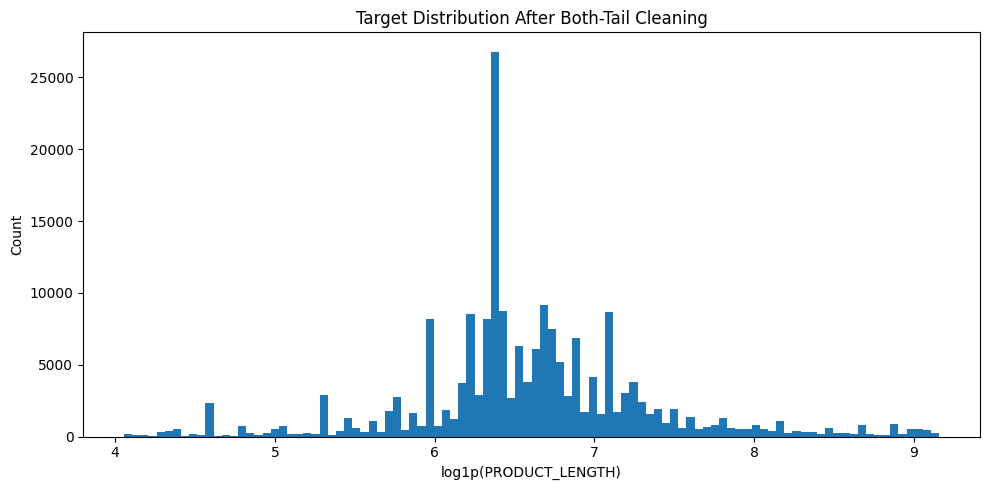

In [16]:

y_clean = train_clean["PRODUCT_LENGTH"].astype(float)

print("Clean target statistics")
print("-----------------------")
print("Minimum :", y_clean.min())
print("Q1      :", y_clean.quantile(0.25))
print("Median  :", y_clean.median())
print("Q3      :", y_clean.quantile(0.75))
print("Maximum :", y_clean.max())
print("Mean    :", y_clean.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log1p(y_clean), bins=100)
ax.set_title("Target Distribution After Both-Tail Cleaning")
ax.set_xlabel("log1p(PRODUCT_LENGTH)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 15. Target buckets after cleaning

In [17]:

post_left_analysis = []

n_clean = len(y_clean)

for t in thresholds:
    count = int((y_clean <= t).sum())
    post_left_analysis.append({
        "threshold": t,
        "count": count,
        "percentage": count / n_clean * 100 if n_clean else 0
    })

post_left_analysis = pd.DataFrame(post_left_analysis)

display(post_left_analysis)


,threshold,count,percentage
0,1,0,0.000000
1,2,0,0.000000
2,3,0,0.000000
3,5,0,0.000000
4,10,0,0.000000
5,20,0,0.000000
6,50,0,0.000000
7,100,4277,2.208133
8,200,10566,5.455024
9,500,44671,23.062785


## 16. Text normalization

In [18]:

ZERO_WIDTH_RE = re.compile(r"[\u200B-\u200D\uFEFF]")
MULTISPACE_RE = re.compile(r"\s+")

def clean_text(s):
    s = s.fillna("").astype("string")
    s = s.str.replace(ZERO_WIDTH_RE, "", regex=True)
    s = s.str.replace("\r", " ", regex=False)
    s = s.str.replace("\n", " ", regex=False)
    s = s.str.replace(MULTISPACE_RE, " ", regex=True)
    s = s.str.strip()
    return s

for col in TEXT_COLS:
    train_clean[col] = clean_text(train_clean[col])
    test[col] = clean_text(test[col])

print("Text normalization complete.")


Text normalization complete.


## 17. Product ID and product type cleaning

In [19]:

bad_train_id = (
    train_clean["PRODUCT_ID"].isna()
    | train_clean["PRODUCT_ID"].str.strip().eq("")
)

bad_test_id = (
    test["PRODUCT_ID"].isna()
    | test["PRODUCT_ID"].str.strip().eq("")
)

print("Invalid train IDs:", bad_train_id.sum())
print("Invalid test IDs :", bad_test_id.sum())

train_clean = train_clean.loc[~bad_train_id].copy()
test = test.loc[~bad_test_id].copy()

# Unknown category rather than dropping the product.
train_clean["PRODUCT_TYPE_ID"] = (
    train_clean["PRODUCT_TYPE_ID"].fillna(-1).astype("int64")
)

test["PRODUCT_TYPE_ID"] = (
    test["PRODUCT_TYPE_ID"].fillna(-1).astype("int64")
)


Invalid train IDs: 0
Invalid test IDs : 0


## 18. Combined text for dimension extraction

In [20]:

def make_combined_text(df):
    return (
        df["TITLE"].fillna("").astype("string") + " " +
        df["BULLET_POINTS"].fillna("").astype("string") + " " +
        df["DESCRIPTION"].fillna("").astype("string")
    ).str.replace(r"\s+", " ", regex=True).str.strip()

train_clean["__TEXT_ALL"] = make_combined_text(train_clean)
test["__TEXT_ALL"] = make_combined_text(test)



## 19. Dimension parser

Extracts:

- `L`
- `W`
- `H`
- `L × W`
- `L × W × H`

and normalizes supported units to centimetres.


In [21]:

NUMBER = r"(\d+(?:\.\d+)?)"
UNIT = r"(mm|millimeters?|cm|centimeters?|m|meters?|in|inch(?:es)?|ft|feet|foot)"
SEP = r"(?:x|×|X|\*)"

DIM_RE = re.compile(
    rf"(?P<a>{NUMBER})\s*(?P<ua>{UNIT})?\s*{SEP}\s*"
    rf"(?P<b>{NUMBER})\s*(?P<ub>{UNIT})?"
    rf"(?:\s*{SEP}\s*(?P<c>{NUMBER})\s*(?P<uc>{UNIT})?)?",
    re.IGNORECASE
)

UNIT_TO_CM = {
    "mm": 0.1,
    "millimeter": 0.1,
    "millimeters": 0.1,
    "cm": 1.0,
    "centimeter": 1.0,
    "centimeters": 1.0,
    "m": 100.0,
    "meter": 100.0,
    "meters": 100.0,
    "in": 2.54,
    "inch": 2.54,
    "inches": 2.54,
    "ft": 30.48,
    "foot": 30.48,
    "feet": 30.48
}

def convert_to_cm(value, unit):
    value = float(value)

    if unit is None:
        return value

    return value * UNIT_TO_CM[unit.lower()]

def parse_dimension(text):
    matches = list(DIM_RE.finditer(str(text)))

    if not matches:
        return np.nan, np.nan, np.nan, 0

    # Prefer a 3-dimensional match.
    matches.sort(
        key=lambda m: (
            m.group("c") is not None,
            m.end() - m.start()
        ),
        reverse=True
    )

    m = matches[0]

    try:
        d1 = convert_to_cm(m.group("a"), m.group("ua"))
        d2 = convert_to_cm(m.group("b"), m.group("ub"))

        if m.group("c") is not None:
            d3 = convert_to_cm(m.group("c"), m.group("uc"))
            return d1, d2, d3, 3

        return d1, d2, np.nan, 2

    except Exception:
        return np.nan, np.nan, np.nan, 0

def extract_dimensions(series):
    parsed = series.map(parse_dimension)

    out = pd.DataFrame(
        parsed.tolist(),
        index=series.index,
        columns=[
            "DIM_1_CM",
            "DIM_2_CM",
            "DIM_3_CM",
            "DIM_COUNT"
        ]
    )

    out["DIM_PRODUCT_2D_CM2"] = (
        out["DIM_1_CM"] * out["DIM_2_CM"]
    )

    out["DIM_VOLUME_CM3"] = (
        out["DIM_1_CM"] *
        out["DIM_2_CM"] *
        out["DIM_3_CM"]
    )

    return out

train_dims = extract_dimensions(train_clean["__TEXT_ALL"])
test_dims = extract_dimensions(test["__TEXT_ALL"])

for col in train_dims.columns:
    train_clean[col] = train_dims[col]
    test[col] = test_dims[col]

display(train_clean[
    [
        "DIM_1_CM",
        "DIM_2_CM",
        "DIM_3_CM",
        "DIM_COUNT",
        "DIM_PRODUCT_2D_CM2",
        "DIM_VOLUME_CM3"
    ]
].head(10))


,DIM_1_CM,DIM_2_CM,DIM_3_CM,DIM_COUNT,DIM_PRODUCT_2D_CM2,DIM_VOLUME_CM3
0,NaN,NaN,NaN,0,NaN,NaN
2,NaN,NaN,NaN,0,NaN,NaN
3,NaN,NaN,NaN,0,NaN,NaN
4,NaN,NaN,NaN,0,NaN,NaN
5,NaN,NaN,NaN,0,NaN,NaN
6,NaN,NaN,NaN,0,NaN,NaN
7,NaN,NaN,NaN,0,NaN,NaN
8,NaN,NaN,NaN,0,NaN,NaN
9,NaN,NaN,NaN,0,NaN,NaN
12,NaN,NaN,NaN,0,NaN,NaN


## 20. Dimension sanity checks

In [22]:

for df in [train_clean, test]:

    for col in ["DIM_1_CM", "DIM_2_CM", "DIM_3_CM"]:

        bad = (
            df[col].notna()
            & (
                ~np.isfinite(df[col])
                | (df[col] <= 0)
                | (df[col] > MAX_DIMENSION_CM)
            )
        )

        df.loc[bad, col] = np.nan

    df["DIM_PRODUCT_2D_CM2"] = (
        df["DIM_1_CM"] * df["DIM_2_CM"]
    )

    df["DIM_VOLUME_CM3"] = (
        df["DIM_1_CM"] *
        df["DIM_2_CM"] *
        df["DIM_3_CM"]
    )

print("Dimension sanity checks complete.")


Dimension sanity checks complete.


## 21. Product-type-aware dimension imputation

In [23]:

DIM_COLS = ["DIM_1_CM", "DIM_2_CM", "DIM_3_CM"]

global_dim_medians = {}
ptype_dim_medians = {}

for col in DIM_COLS:

    global_median = train_clean[col].median()

    if not np.isfinite(global_median):
        global_median = 1.0

    global_dim_medians[col] = float(global_median)

    medians = (
        train_clean
        .groupby("PRODUCT_TYPE_ID")[col]
        .median()
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    ptype_dim_medians[col] = {
        str(k): float(v)
        for k, v in medians.items()
    }

    train_clean[col] = train_clean[col].fillna(
        train_clean["PRODUCT_TYPE_ID"].map(medians)
    )

    test[col] = test[col].fillna(
        test["PRODUCT_TYPE_ID"].map(medians)
    )

    train_clean[col] = train_clean[col].fillna(global_median)
    test[col] = test[col].fillna(global_median)

for df in [train_clean, test]:

    df["DIM_PRODUCT_2D_CM2"] = (
        df["DIM_1_CM"] * df["DIM_2_CM"]
    )

    df["DIM_VOLUME_CM3"] = (
        df["DIM_1_CM"] *
        df["DIM_2_CM"] *
        df["DIM_3_CM"]
    )

print("Dimension imputation complete.")


Dimension imputation complete.


## 22. Dimension availability flags

In [24]:

train_clean["HAS_DIMENSION_2D"] = (
    train_dims["DIM_COUNT"] >= 2
).astype("int8")

train_clean["HAS_DIMENSION_3D"] = (
    train_dims["DIM_COUNT"] >= 3
).astype("int8")

test["HAS_DIMENSION_2D"] = (
    test_dims["DIM_COUNT"] >= 2
).astype("int8")

test["HAS_DIMENSION_3D"] = (
    test_dims["DIM_COUNT"] >= 3
).astype("int8")

print("Dimension flags added.")


Dimension flags added.


## 23. Text quality features

In [25]:

def add_text_quality_features(df):

    for col, prefix in [
        ("TITLE", "TITLE"),
        ("BULLET_POINTS", "BULLET"),
        ("DESCRIPTION", "DESC")
    ]:

        s = df[col].fillna("").astype("string")

        df[f"{prefix}_CHAR_COUNT"] = (
            s.str.len().fillna(0).astype("int32")
        )

        df[f"{prefix}_WORD_COUNT"] = (
            s.str.split().str.len().fillna(0).astype("int32")
        )

        df[f"{prefix}_DIGIT_COUNT"] = (
            s.str.count(r"\d").fillna(0).astype("int32")
        )

        df[f"{prefix}_EMPTY"] = (
            s.str.strip().eq("").astype("int8")
        )

    return df

train_clean = add_text_quality_features(train_clean)
test = add_text_quality_features(test)


## 24. Measurement-unit indicators

In [26]:

UNIT_RE = re.compile(
    r"\b(?:mm|millimeters?|cm|centimeters?|m|meters?|"
    r"in|inch(?:es)?|ft|feet|foot|kg|g|lb|lbs|oz)\b",
    re.IGNORECASE
)

for df in [train_clean, test]:

    df["HAS_MEASUREMENT_UNIT"] = (
        df["__TEXT_ALL"]
        .fillna("")
        .astype("string")
        .str.contains(UNIT_RE, regex=True, na=False)
        .astype("int8")
    )

print("Measurement indicators added.")


Measurement indicators added.


## 25. Train/test leakage checks

In [27]:

overlap = (
    set(train_clean["PRODUCT_ID"])
    & set(test["PRODUCT_ID"])
)

print("Train/Test PRODUCT_ID overlap:", len(overlap))

assert len(overlap) == 0
assert train_clean["PRODUCT_ID"].is_unique
assert test["PRODUCT_ID"].is_unique

assert "PRODUCT_LENGTH" not in test.columns

assert train_clean["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train_clean["PRODUCT_LENGTH"]).all()
assert (train_clean["PRODUCT_LENGTH"] > 0).all()

print("Leakage checks PASSED.")


Train/Test PRODUCT_ID overlap: 0
Leakage checks PASSED.


## 26. Final data-quality report

In [28]:

def quality_report(df, name, target=False):

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    print("Duplicate PRODUCT_ID:", df["PRODUCT_ID"].duplicated().sum())

    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    print("\nMissing values:")
    if len(missing):
        display(missing.to_frame("count"))
    else:
        print("None")

    if target:

        y = df["PRODUCT_LENGTH"]

        print("\nTarget statistics:")
        print("min    :", y.min())
        print("Q1     :", y.quantile(0.25))
        print("median :", y.median())
        print("Q3     :", y.quantile(0.75))
        print("max    :", y.max())
        print("mean   :", y.mean())

quality_report(train_clean, "CLEAN TRAIN", target=True)
quality_report(test, "CLEAN TEST", target=False)


CLEAN TRAIN
Shape: (193693, 28)
Duplicate rows: 0
Duplicate PRODUCT_ID: 0

Missing values:
None

Target statistics:
min    : 56.6928
Q1     : 531.495
median : 669.2913379
Q3     : 1050.0
max    : 9500.0
mean   : 1013.6051301996049
CLEAN TEST
Shape: (50000, 27)
Duplicate rows: 0
Duplicate PRODUCT_ID: 0

Missing values:
None


## 27. Cleaning summary

In [29]:

reason_summary = (
    audit[audit["removed"]]
    ["reason"]
    .value_counts()
    .rename_axis("reason")
    .reset_index(name="count")
)

reason_summary["percentage_of_raw_train"] = (
    reason_summary["count"] / len(train) * 100
)

display(reason_summary)

print("\nTotal removed:", audit["removed"].sum())
print("Final train  :", len(train_clean))


,reason,count,percentage_of_raw_train
0,extreme_left_target_outlier,4164,2.0820
1,extreme_right_target_outlier,2143,1.0715



Total removed: 6307
Final train  : 193693


## 28. Save cleaning rules

In [30]:

rules = {
    "data_mode": DATA_MODE,

    "target": {
        "column": "PRODUCT_LENGTH",
        "transform": "log1p",
        "left_rule": "Q1 - 3*IQR",
        "right_rule": "Q3 + 3*IQR",
        "log_q1": q1_log,
        "log_q3": q3_log,
        "log_iqr": iqr_log,
        "robust_lower": robust_lower,
        "robust_upper": robust_upper,
        "final_lower": final_lower,
        "final_upper": final_upper
    },

    "duplicates": {
        "exact_rows": "keep_first",
        "PRODUCT_ID": "keep_first"
    },

    "dimensions": {
        "unit": "cm",
        "max_dimension_cm": MAX_DIMENSION_CM,
        "imputation": "PRODUCT_TYPE_ID median -> global training median -> 1.0"
    },

    "text": {
        "missing_to_empty": True,
        "remove_zero_width_characters": True,
        "normalize_whitespace": True,
        "strip": True
    }
}

with open(RULES_FILE, "w", encoding="utf-8") as f:
    json.dump(rules, f, indent=2)

print("Saved:", RULES_FILE)


Saved: ../dataset/cleaned\cleaning_rules_experiment.json


## 29. Remove internal parser text

In [ ]:
train_clean = train_clean.drop(columns=["__TEXT_ALL"])
test = test.drop(columns=["__TEXT_ALL"])

print("Internal helper column removed.")


Internal helper column removed.


## 30. Save final clean datasets and audit

In [32]:

train_clean.to_csv(CLEAN_TRAIN_FILE, index=False)
test.to_csv(CLEAN_TEST_FILE, index=False)

audit_to_save = audit.copy()
audit_to_save["original_row_index"] = audit_to_save.index

audit_to_save.to_csv(AUDIT_FILE, index=False)

print("Files written:")
print("  ", CLEAN_TRAIN_FILE)
print("  ", CLEAN_TEST_FILE)
print("  ", AUDIT_FILE)
print("  ", RULES_FILE)


Files written:
   ../dataset/cleaned\train_clean_experiment.csv
   ../dataset/cleaned\test_clean_experiment.csv
   ../dataset/cleaned\cleaning_audit_experiment.csv
   ../dataset/cleaned\cleaning_rules_experiment.json



# Notebook 02 Complete

The output of this notebook is the clean data boundary:

```text
dataset/cleaned/
├── train_clean_<mode>.csv
├── test_clean_<mode>.csv
├── cleaning_audit_<mode>.csv
└── cleaning_rules_<mode>.json
```

## Important modeling principle

Do **not** remove legitimate small products just to improve MAPE.

The purpose of the left-tail analysis is to identify **genuine anomalous/corrupted observations**, not to manipulate the evaluation metric.

After this notebook:

```text
Raw data
   ↓
Cleaning
   ├── invalid records
   ├── duplicates
   ├── left-tail anomalies
   └── right-tail anomalies
   ↓
Text normalization
   ↓
Dimension extraction
   ↓
Dimension normalization
   ↓
Training-only imputation
   ↓
Clean dataset
   ↓
Notebook 03 / NLP
```

The next stage can safely focus on **TF-IDF, character n-grams, numerical features, and model training**.
